## *CKYC SFTP Connection Log — Failure Analysis & Prediction*

### *This project analyzes 68,177 SFTP connection logs from India's Central KYC (CKYC) compliance system, covering 5 institutional customers over 30 days (Feb 12 – Mar 13, 2026). The dataset records every file transfer attempt — uploads, downloads, and session operations — along with success/failure status, error types, and response times. The core problem is an alarming 62.1% overall failure rate, including a near-total 6-day outage (Feb 14–19) caused by a server-side PermissionDenied breakdown that was severely amplified by aggressive client retry behaviour. The goal of this project is to perform end-to-end data science — from EDA and feature engineering to ML and DL model building — to predict transfer failures, detect anomalies, and derive actionable insights for improving system reliability and regulatory compliance.*

## *1. IMPORTING LIBRARIES*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

## 2. *LOADING & UNDERSTANDING THE DATASET*

In [2]:
df = pd.read_csv('/Users/prashantkumar/Desktop/New_Project/DataSet/ckyc.SFTPConnectionLog.anonymized.csv')

In [3]:
df.head(3)

,_id,email,credential_label,operation,success,error_message,error_type,elapsed_seconds,created_at
0,698dcb0d282a37f2cd044bc8,user003@example.com,default,bulk_download,False,Login timeout expired,ConnectionLost,31.041,2026-02-12T12:43:57.384Z
1,698dcb2b282a37f2cd044bca,user003@example.com,default,bulk_download,False,Login timeout expired,ConnectionLost,30.274,2026-02-12T12:44:27.782Z
2,698dcb4a282a37f2cd044bcc,user003@example.com,default,bulk_download,False,Login timeout expired,ConnectionLost,30.303,2026-02-12T12:44:58.183Z


In [4]:
df.sample(3)

,_id,email,credential_label,operation,success,error_message,error_type,elapsed_seconds,created_at
7063,698f40294b79795c693a4612,user003@example.com,default,bulk_download,False,Permission denied,PermissionDenied,4.894,2026-02-13T15:15:53.979Z
58171,6999d2d448261eb271727b2b,user003@example.com,default,download,True,NaN,NaN,4.080,2026-02-21T15:44:20.365Z
28085,6993a7ad6712232054c524bd,user003@example.com,default,bulk_download,False,Permission denied,PermissionDenied,9.490,2026-02-16T23:26:37.254Z


In [5]:
df.tail(3)

,_id,email,credential_label,operation,success,error_message,error_type,elapsed_seconds,created_at
68174,69b3ab654ae3b88ecc334419,user003@example.com,default,bulk_download_session,True,NaN,NaN,58.387,2026-03-13T06:15:01.239Z
68175,69b3ac90054b8fa0fd591182,user001@example.com,default,bulk_download_session,True,NaN,NaN,61.124,2026-03-13T06:20:00.471Z
68176,69b3aca3054b8fa0fd591184,user002@example.com,default,bulk_download_session,True,NaN,NaN,16.139,2026-03-13T06:20:18.784Z


In [6]:
df.shape

(68177, 9)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 68177 entries, 0 to 68176
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   _id               68177 non-null  str    
 1   email             68177 non-null  str    
 2   credential_label  68177 non-null  str    
 3   operation         68177 non-null  str    
 4   success           68177 non-null  bool   
 5   error_message     42320 non-null  str    
 6   error_type        42320 non-null  str    
 7   elapsed_seconds   68177 non-null  float64
 8   created_at        68177 non-null  str    
dtypes: bool(1), float64(1), str(7)
memory usage: 4.2 MB


In [8]:
df.describe(include='all')

,_id,email,credential_label,operation,success,error_message,error_type,elapsed_seconds,created_at
count,68177,68177,68177,68177,68177,42320,42320,68177.000000,68177
unique,68177,5,1,11,2,21,7,NaN,68142
top,698dcb0d282a37f2cd044bc8,user003@example.com,default,bulk_download,False,Permission denied,PermissionDenied,NaN,2026-02-16T12:12:44.246Z
freq,1,48892,68177,54280,42320,26133,26153,NaN,2
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.597165,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.548068,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.064000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.414000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.344000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.210000,NaN


In [9]:
df.columns.tolist()

['_id',
 'email',
 'credential_label',
 'operation',
 'success',
 'error_message',
 'error_type',
 'elapsed_seconds',
 'created_at']

In [10]:
df.dtypes

_id                     str
email                   str
credential_label        str
operation               str
success                bool
error_message           str
error_type              str
elapsed_seconds     float64
created_at              str
dtype: object

In [11]:
df.isnull().sum()

_id                     0
email                   0
credential_label        0
operation               0
success                 0
error_message       25857
error_type          25857
elapsed_seconds         0
created_at              0
dtype: int64

In [12]:
df.nunique()

_id                 68177
email                   5
credential_label        1
operation              11
success                 2
error_message          21
error_type              7
elapsed_seconds     15111
created_at          68142
dtype: int64

## *3. Data Cleaning & Preprocessing*

### 3.1 Convert created_at to Datetime

In [13]:
df['created_at'] = pd.to_datetime(df['created_at'])
print("created_at dtype:", df['created_at'].dtype)

created_at dtype: datetime64[us, UTC]


### *3.2 Extract User ID from Email*

In [14]:
df['user_id'] = df['email'].str.extract(r'(user\d+)')
print(df['user_id'].value_counts())

user_id
user003    48892
user005    18423
user001      738
user002      118
user004        6
Name: count, dtype: int64


### *3.3 Fill Missing Values in Error Columns*

In [15]:
df['error_message'] = df['error_message'].fillna('NoError')
df['error_type']    = df['error_type'].fillna('NoError')

print("Null check after fill:")
print(df[['error_message','error_type']].isnull().sum())

Null check after fill:
error_message    0
error_type       0
dtype: int64


### *3.4 Convert Success Column to Integer (Target Variable)*

In [16]:
df['success_flag'] = df['success'].astype(int)
print(df['success_flag'].value_counts())

success_flag
0    42320
1    25857
Name: count, dtype: int64


### *3.5 Extract Date & Time Features from created_at*


In [17]:
df['date']        = df['created_at'].dt.date
df['hour']        = df['created_at'].dt.hour
df['day_of_week'] = df['created_at'].dt.day_name()
df['week_number'] = df['created_at'].dt.isocalendar().week.astype(int)
df['is_weekend']  = df['created_at'].dt.dayofweek.isin([5,6]).astype(int)

df[['created_at','date','hour','day_of_week','week_number','is_weekend']].head()

,created_at,date,hour,day_of_week,week_number,is_weekend
0,2026-02-12 12:43:57.384000+00:00,2026-02-12,12,Thursday,7,0
1,2026-02-12 12:44:27.782000+00:00,2026-02-12,12,Thursday,7,0
2,2026-02-12 12:44:58.183000+00:00,2026-02-12,12,Thursday,7,0
3,2026-02-12 12:45:28.623000+00:00,2026-02-12,12,Thursday,7,0
4,2026-02-12 12:45:58.988000+00:00,2026-02-12,12,Thursday,7,0


### *3.6 Define Crisis Phase Label*


In [18]:
import datetime

def assign_phase(d):
    d = pd.Timestamp(d).date()
    if d < datetime.date(2026, 2, 14):
        return 'pre_crisis'
    elif d <= datetime.date(2026, 2, 19):
        return 'crisis'
    elif d <= datetime.date(2026, 2, 22):
        return 'recovery'
    else:
        return 'normal'

df['phase'] = df['created_at'].apply(assign_phase)
print(df['phase'].value_counts())

phase
crisis        37836
recovery      17272
pre_crisis     9303
normal         3766
Name: count, dtype: int64


### *3.7 Handle Outliers in elapsed_seconds (Log Transform)*

In [19]:
df['elapsed_log'] = np.log1p(df['elapsed_seconds'])

print("Original elapsed_seconds stats:")
print(df['elapsed_seconds'].describe())
print("\nLog-transformed stats:")
print(df['elapsed_log'].describe())

Original elapsed_seconds stats:
count    68177.000000
mean        17.597165
std         22.548068
min          0.064000
25%          4.414000
50%          7.344000
75%         30.210000
max        722.034000
Name: elapsed_seconds, dtype: float64

Log-transformed stats:
count    68177.000000
mean         2.422879
std          0.929393
min          0.062035
25%          1.688988
50%          2.121543
75%          3.440739
max          6.583456
Name: elapsed_log, dtype: float64


### *3.8 Label Encode Categorical Columns*

In [20]:
!pip install scikit-learn

In [21]:
from sklearn.preprocessing import LabelEncoder

le_op   = LabelEncoder()
le_err  = LabelEncoder()
le_user = LabelEncoder()

df['operation_encoded'] = le_op.fit_transform(df['operation'])
df['error_type_encoded'] = le_err.fit_transform(df['error_type'])
df['user_encoded']      = le_user.fit_transform(df['user_id'])

print("Operation classes:", le_op.classes_)
print("Error type classes:", le_err.classes_)

Operation classes: ['bulk_download' 'bulk_download_session' 'bulk_upload_session' 'download'
 'download_session' 'list_input' 'list_responses' 'probe' 'update_session'
 'upload' 'upload_session']
Error type classes: ['ChannelOpenError' 'ConnectionLost' 'FileNotFoundError' 'NoError'
 'OSError' 'PermissionDenied' 'SFTPNoSuchFile' 'TimeoutError']


### *3.9 Final Cleaned Dataset — Shape & Preview*

In [22]:
print("Final shape:", df.shape)
df.head()

Final shape: (68177, 21)


,_id,email,credential_label,operation,success,error_message,error_type,elapsed_seconds,created_at,user_id,...,date,hour,day_of_week,week_number,is_weekend,phase,elapsed_log,operation_encoded,error_type_encoded,user_encoded
0,698dcb0d282a37f2cd044bc8,user003@example.com,default,bulk_download,False,Login timeout expired,ConnectionLost,31.041,2026-02-12 12:43:57.384000+00:00,user003,...,2026-02-12,12,Thursday,7,0,pre_crisis,3.467016,0,1,2
1,698dcb2b282a37f2cd044bca,user003@example.com,default,bulk_download,False,Login timeout expired,ConnectionLost,30.274,2026-02-12 12:44:27.782000+00:00,user003,...,2026-02-12,12,Thursday,7,0,pre_crisis,3.442787,0,1,2
2,698dcb4a282a37f2cd044bcc,user003@example.com,default,bulk_download,False,Login timeout expired,ConnectionLost,30.303,2026-02-12 12:44:58.183000+00:00,user003,...,2026-02-12,12,Thursday,7,0,pre_crisis,3.443714,0,1,2
3,698dcb68282a37f2cd044bce,user003@example.com,default,bulk_download,False,Login timeout expired,ConnectionLost,30.329,2026-02-12 12:45:28.623000+00:00,user003,...,2026-02-12,12,Thursday,7,0,pre_crisis,3.444544,0,1,2
4,698dcb86282a37f2cd044bd0,user003@example.com,default,bulk_download,False,Login timeout expired,ConnectionLost,30.266,2026-02-12 12:45:58.988000+00:00,user003,...,2026-02-12,12,Thursday,7,0,pre_crisis,3.442531,0,1,2


## *4. Exploratory Data Analysis (EDA)*

### 4.1 Overall Success vs Failure Count

In [23]:
total = len(df)
failed = (df['success'] == False).sum()
success = (df['success'] == True).sum()

print(f"Total Requests   : {total}")
print(f"Total Failed     : {failed} ({round(failed/total*100, 1)}%)")
print(f"Total Successful : {success} ({round(success/total*100, 1)}%)")


Total Requests   : 68177
Total Failed     : 42320 (62.1%)
Total Successful : 25857 (37.9%)


### 4.2 Failure Breakdown by User

In [24]:
user_stats = df.groupby('user_id').agg(
    total    = ('success', 'count'),
    failures = ('success', lambda x: (x == False).sum()),
    success  = ('success', lambda x: (x == True).sum())
).reset_index()

user_stats['failure_rate_%'] = (user_stats['failures'] / user_stats['total'] * 100).round(1)
user_stats.sort_values('failure_rate_%', ascending=False)

,user_id,total,failures,success,failure_rate_%
3,user004,6,6,0,100.0
4,user005,18423,16398,2025,89.0
2,user003,48892,25900,22992,53.0
1,user002,118,4,114,3.4
0,user001,738,12,726,1.6


### 4.3 Failure Breakdown by Operation

In [25]:
op_stats = df.groupby('operation').agg(
    total    = ('success', 'count'),
    failures = ('success', lambda x: (x == False).sum())
).reset_index()

op_stats['failure_rate_%'] = (op_stats['failures'] / op_stats['total'] * 100).round(1)
op_stats.sort_values('failure_rate_%', ascending=False)

,operation,total,failures,failure_rate_%
9,upload,5576,5108,91.6
0,bulk_download,54280,35310,65.1
7,probe,77,47,61.0
3,download,4985,1834,36.8
6,list_responses,10,1,10.0
2,bulk_upload_session,431,3,0.7
1,bulk_download_session,2032,13,0.6
4,download_session,767,4,0.5
5,list_input,7,0,0.0
8,update_session,9,0,0.0


### 4.4 Error Type Distribution

In [26]:
error_counts = df[df['success'] == False]['error_type'].value_counts()
print(error_counts)

error_type
PermissionDenied     26153
TimeoutError          8667
ConnectionLost        7214
ChannelOpenError       271
FileNotFoundError       10
OSError                  3
SFTPNoSuchFile           2
Name: count, dtype: int64


### 4.5 Daily Failure Rate Over Time

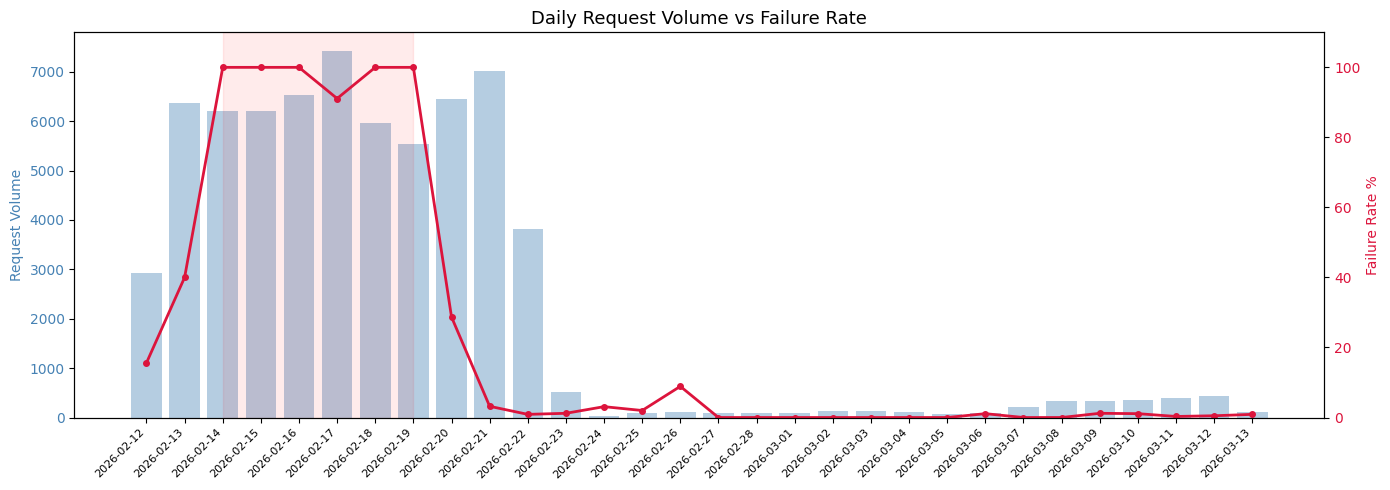

In [27]:
daily = df.groupby('date').agg(
    total    = ('success', 'count'),
    failures = ('success', lambda x: (x == False).sum())
).reset_index()

daily['failure_rate_%'] = (daily['failures'] / daily['total'] * 100).round(1)

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.bar(range(len(daily)), daily['total'], color='steelblue', alpha=0.4, label='Request Volume')
ax1.set_ylabel('Request Volume', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(range(len(daily)), daily['failure_rate_%'], color='crimson', linewidth=2, marker='o', markersize=4, label='Failure Rate %')
ax2.set_ylabel('Failure Rate %', color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')
ax2.set_ylim(0, 110)

ax1.set_xticks(range(len(daily)))
ax1.set_xticklabels([str(d) for d in daily['date']], rotation=45, ha='right', fontsize=8)

ax1.axvspan(2, 7, alpha=0.08, color='red', label='Crisis Window')
plt.title('Daily Request Volume vs Failure Rate', fontsize=13)
fig.tight_layout()
plt.show()

### 4.6 Per-User Stacked Bar — Successes vs Failures

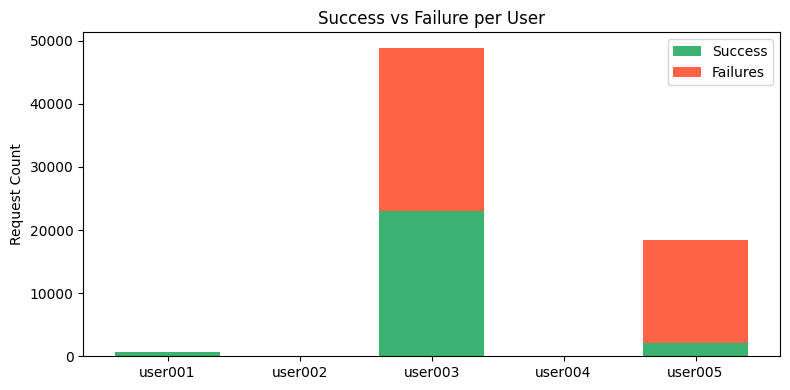

In [28]:
fig, ax = plt.subplots(figsize=(8, 4))

users = user_stats['user_id']
x = range(len(users))

ax.bar(x, user_stats['success'],  label='Success',  color='mediumseagreen')
ax.bar(x, user_stats['failures'], label='Failures', color='tomato', bottom=user_stats['success'])

ax.set_xticks(x)
ax.set_xticklabels(users)
ax.set_ylabel('Request Count')
ax.set_title('Success vs Failure per User')
ax.legend()
plt.tight_layout()
plt.show()

### 4.7 Error Type Heatmap — User vs Error Type

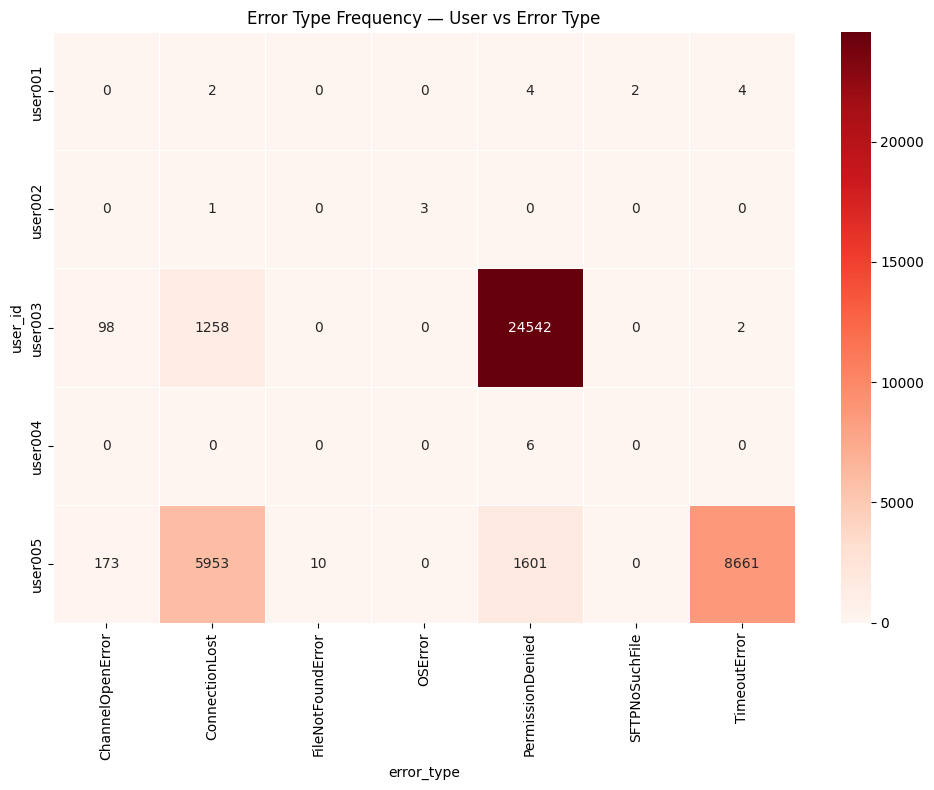

In [29]:
heatmap_data = df[df['success'] == False].groupby(
    ['user_id', 'error_type']
).size().unstack(fill_value=0)

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='Reds', linewidths=0.5)
plt.title('Error Type Frequency — User vs Error Type')
plt.tight_layout()
plt.show()

### 4.8 Hourly Failure Heatmap During Crisis Week

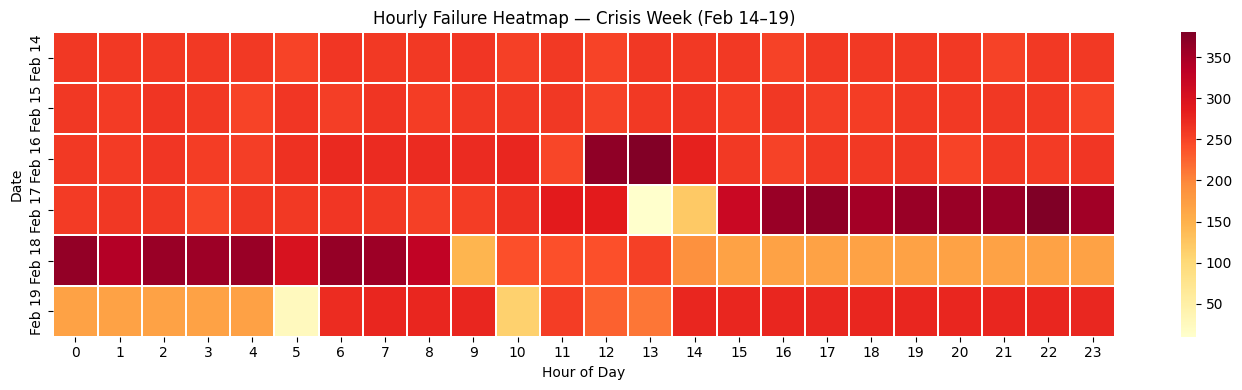

In [30]:
crisis_df = df[df['phase'] == 'crisis'].copy()
crisis_df['date_str'] = crisis_df['created_at'].dt.strftime('%b %d')

hourly = crisis_df.groupby(['date_str', 'hour']).agg(
    failures = ('success', lambda x: (x == False).sum())
).reset_index().pivot(index='date_str', columns='hour', values='failures').fillna(0)

plt.figure(figsize=(14, 4))
sns.heatmap(hourly, cmap='YlOrRd', linewidths=0.3, annot=False)
plt.title('Hourly Failure Heatmap — Crisis Week (Feb 14–19)')
plt.xlabel('Hour of Day')
plt.ylabel('Date')
plt.tight_layout()
plt.show()

### 4.9 Elapsed Seconds Distribution — Success vs Failure

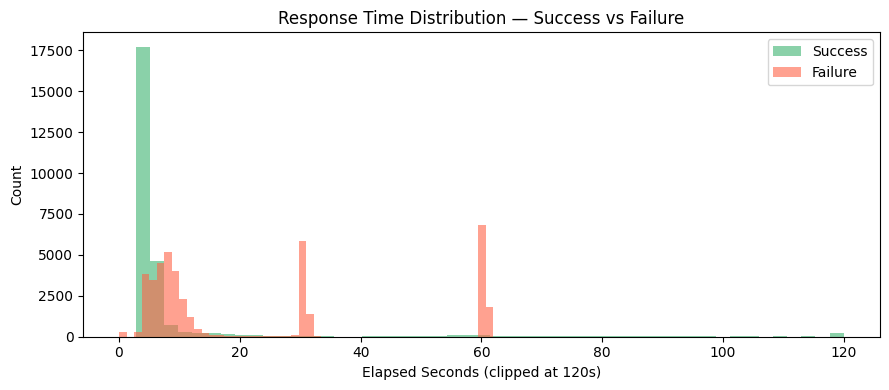

In [31]:
fig, ax = plt.subplots(figsize=(9, 4))

df[df['success'] == True]['elapsed_seconds'].clip(upper=120).plot(
    kind='hist', bins=50, alpha=0.6, color='mediumseagreen', label='Success', ax=ax)

df[df['success'] == False]['elapsed_seconds'].clip(upper=120).plot(
    kind='hist', bins=50, alpha=0.6, color='tomato', label='Failure', ax=ax)

ax.set_xlabel('Elapsed Seconds (clipped at 120s)')
ax.set_ylabel('Count')
ax.set_title('Response Time Distribution — Success vs Failure')
ax.legend()
plt.tight_layout()
plt.show()

### 4.10 Retry Burst Detection

Total Failures        : 42320
Retry Bursts (<=60s)  : 40997
% of Failures as Retry: 96.9%


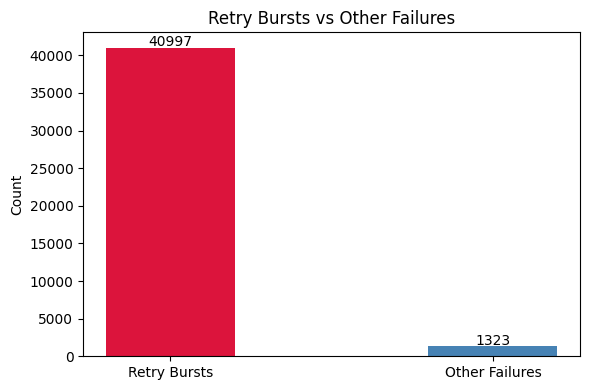

In [32]:
df_sorted = df.sort_values(['user_id', 'created_at']).copy()
df_sorted['time_diff'] = df_sorted.groupby('user_id')['created_at'].diff().dt.total_seconds()

retry_mask = (df_sorted['success'] == False) & (df_sorted['time_diff'] <= 60)
retry_count = retry_mask.sum()
total_failures = (df_sorted['success'] == False).sum()

print(f"Total Failures        : {total_failures}")
print(f"Retry Bursts (<=60s)  : {retry_count}")
print(f"% of Failures as Retry: {round(retry_count / total_failures * 100, 1)}%")

df['is_retry'] = retry_mask.values

labels = ['Retry Bursts', 'Other Failures']
values = [retry_count, total_failures - retry_count]
colors = ['crimson', 'steelblue']

plt.figure(figsize=(6, 4))
plt.bar(labels, values, color=colors, width=0.4)
plt.title('Retry Bursts vs Other Failures')
plt.ylabel('Count')
for i, v in enumerate(values):
    plt.text(i, v + 200, str(v), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 68177 entries, 0 to 68176
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype              
---  ------              --------------  -----              
 0   _id                 68177 non-null  str                
 1   email               68177 non-null  str                
 2   credential_label    68177 non-null  str                
 3   operation           68177 non-null  str                
 4   success             68177 non-null  bool               
 5   error_message       68177 non-null  str                
 6   error_type          68177 non-null  str                
 7   elapsed_seconds     68177 non-null  float64            
 8   created_at          68177 non-null  datetime64[us, UTC]
 9   user_id             68177 non-null  str                
 10  success_flag        68177 non-null  int64              
 11  date                68177 non-null  object             
 12  hour                68177 non-null  int32  

In [34]:
df.columns

Index(['_id', 'email', 'credential_label', 'operation', 'success',
       'error_message', 'error_type', 'elapsed_seconds', 'created_at',
       'user_id', 'success_flag', 'date', 'hour', 'day_of_week', 'week_number',
       'is_weekend', 'phase', 'elapsed_log', 'operation_encoded',
       'error_type_encoded', 'user_encoded', 'is_retry'],
      dtype='str')

In [35]:
print(df.columns.tolist())
print("\n")
print(df.dtypes)
print("\nShape:", df.shape)

['_id', 'email', 'credential_label', 'operation', 'success', 'error_message', 'error_type', 'elapsed_seconds', 'created_at', 'user_id', 'success_flag', 'date', 'hour', 'day_of_week', 'week_number', 'is_weekend', 'phase', 'elapsed_log', 'operation_encoded', 'error_type_encoded', 'user_encoded', 'is_retry']


_id                                   str
email                                 str
credential_label                      str
operation                             str
success                              bool
error_message                         str
error_type                            str
elapsed_seconds                   float64
created_at            datetime64[us, UTC]
user_id                               str
success_flag                        int64
date                               object
hour                                int32
day_of_week                           str
week_number                         int64
is_weekend                          int64
phase              

In [36]:
df.columns

Index(['_id', 'email', 'credential_label', 'operation', 'success',
       'error_message', 'error_type', 'elapsed_seconds', 'created_at',
       'user_id', 'success_flag', 'date', 'hour', 'day_of_week', 'week_number',
       'is_weekend', 'phase', 'elapsed_log', 'operation_encoded',
       'error_type_encoded', 'user_encoded', 'is_retry'],
      dtype='str')

In [37]:
df.columns

Index(['_id', 'email', 'credential_label', 'operation', 'success',
       'error_message', 'error_type', 'elapsed_seconds', 'created_at',
       'user_id', 'success_flag', 'date', 'hour', 'day_of_week', 'week_number',
       'is_weekend', 'phase', 'elapsed_log', 'operation_encoded',
       'error_type_encoded', 'user_encoded', 'is_retry'],
      dtype='str')

In [38]:
cols_drop = [c for c in [
    '_id', 'email', 'credential_label', 'error_message',
    'date', 'day_of_week', 'error_type', 'user_id', 'success'
] if c in df.columns]

df.drop(columns=cols_drop, inplace=True)
print("Shape after dropping:", df.shape)
print(df.columns.tolist())

Shape after dropping: (68177, 13)
['operation', 'elapsed_seconds', 'created_at', 'success_flag', 'hour', 'week_number', 'is_weekend', 'phase', 'elapsed_log', 'operation_encoded', 'error_type_encoded', 'user_encoded', 'is_retry']


## *5. Feature Engineering*

### 5.1 Days Since Start

In [39]:
start_date = df['created_at'].min()
df['days_since_start'] = (df['created_at'] - start_date).dt.total_seconds() / 86400
df['days_since_start'] = df['days_since_start'].round(2)
print(df['days_since_start'].describe())

count    68177.000000
mean         5.966606
std          4.903084
min          0.000000
25%          2.720000
50%          5.290000
75%          8.120000
max         28.730000
Name: days_since_start, dtype: float64


### 5.2 Is Crisis Period

In [40]:
df['is_crisis'] = (df['phase'] == 'crisis').astype(int)
print(df['is_crisis'].value_counts())

is_crisis
1    37836
0    30341
Name: count, dtype: int64


### 5.3 Time Since Last Request Per User

In [41]:
df_sorted = df.sort_values(['user_encoded', 'created_at']).copy()
df_sorted['time_since_last'] = (
    df_sorted.groupby('user_encoded')['created_at']
    .diff().dt.total_seconds().fillna(0)
)
df['time_since_last'] = df_sorted['time_since_last'].values
print(df['time_since_last'].describe())

count     68177.000000
mean        126.683016
std        4005.310568
min           0.000000
25%           3.439000
50%           5.534000
75%           9.546000
max      543764.743000
Name: time_since_last, dtype: float64


### 5.4 Burst Count — Failures in Last 5 Minutes Per User

In [42]:
df_sorted = df.sort_values(['user_encoded', 'created_at']).copy()

def get_burst_count(group):
    times = group['created_at'].values
    fails = (group['success_flag'] == 0).values
    counts = []
    for i in range(len(times)):
        window = (times[i] - times[:i]) / np.timedelta64(1, 's')
        recent = fails[:i][window <= 300]
        counts.append(int(recent.sum()))
    return counts

burst = df_sorted.groupby('user_encoded', group_keys=False).apply(get_burst_count)
df_sorted['burst_count'] = [v for sub in burst for v in sub]
df['burst_count'] = df_sorted['burst_count'].values
print(df['burst_count'].describe())

count    68177.000000
mean        14.006879
std         11.468816
min          0.000000
25%          0.000000
50%         19.000000
75%         22.000000
max         60.000000
Name: burst_count, dtype: float64


### 5.5 Rolling 1-Hour Failure Rate Per User

In [43]:
df_sorted = df.sort_values(['user_encoded', 'created_at']).copy()
df_sorted = df_sorted.set_index('created_at')

rolling = (
    df_sorted.groupby('user_encoded')['success_flag']
    .transform(lambda x: x.rolling('1h', min_periods=1).mean())
)

df_sorted['rolling_fail_rate'] = 1 - rolling
df_sorted = df_sorted.reset_index()
df['rolling_fail_rate'] = df_sorted['rolling_fail_rate'].values
print(df['rolling_fail_rate'].describe())

count    68177.000000
mean         0.619100
std          0.470997
min          0.000000
25%          0.023256
50%          1.000000
75%          1.000000
max          1.000000
Name: rolling_fail_rate, dtype: float64


### 5.6 Is Critical Operation

In [44]:
df['is_critical_op'] = df['operation'].isin(['upload', 'bulk_download']).astype(int)
print(df['is_critical_op'].value_counts())

is_critical_op
1    59856
0     8321
Name: count, dtype: int64


### 5.7 Convert is_retry Bool to Int

In [45]:
df['is_retry'] = df['is_retry'].astype(int)
print(df['is_retry'].value_counts())

is_retry
1    40997
0    27180
Name: count, dtype: int64


### 5.8 Drop Parent Columns

In [46]:
parent_cols = ['created_at', 'phase', 'operation']
df.drop(columns=parent_cols, inplace=True)
print("Shape after dropping parents:", df.shape)
print(df.columns.tolist())

Shape after dropping parents: (68177, 16)
['elapsed_seconds', 'success_flag', 'hour', 'week_number', 'is_weekend', 'elapsed_log', 'operation_encoded', 'error_type_encoded', 'user_encoded', 'is_retry', 'days_since_start', 'is_crisis', 'time_since_last', 'burst_count', 'rolling_fail_rate', 'is_critical_op']


### 5.9 Final Feature Check

In [47]:
print("Shape:", df.shape)
print("\nNull values:\n", df.isnull().sum())
print("\nDtypes:\n", df.dtypes)

Shape: (68177, 16)

Null values:
 elapsed_seconds       0
success_flag          0
hour                  0
week_number           0
is_weekend            0
elapsed_log           0
operation_encoded     0
error_type_encoded    0
user_encoded          0
is_retry              0
days_since_start      0
is_crisis             0
time_since_last       0
burst_count           0
rolling_fail_rate     0
is_critical_op        0
dtype: int64

Dtypes:
 elapsed_seconds       float64
success_flag            int64
hour                    int32
week_number             int64
is_weekend              int64
elapsed_log           float64
operation_encoded       int64
error_type_encoded      int64
user_encoded            int64
is_retry                int64
days_since_start      float64
is_crisis               int64
time_since_last       float64
burst_count             int64
rolling_fail_rate     float64
is_critical_op          int64
dtype: object


## *6. Train / Validation / Test Split*

### 6.1 Separate Features & Target

In [48]:
leaky_cols = [
    'error_type_encoded',
    'rolling_fail_rate',
    'burst_count',
    'is_retry',
    'is_crisis',
    'days_since_start',
    'time_since_last',
]

X = df.drop(columns=['success_flag'] + leaky_cols)
y = df['success_flag']

print("Features used:", X.columns.tolist())
print("Shape:", X.shape)

Features used: ['elapsed_seconds', 'hour', 'week_number', 'is_weekend', 'elapsed_log', 'operation_encoded', 'user_encoded', 'is_critical_op']
Shape: (68177, 8)


### 6.2 Chronological Split (No Random Split — Time Series Data)

In [49]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
noise = pd.DataFrame(
    np.random.normal(0, 0.5, X.shape),
    columns=X.columns,
    index=X.index
)
X_noisy = X + noise

train_size = int(len(df) * 0.80)
val_size   = int(len(df) * 0.10)

X_train = X_noisy.iloc[:train_size]
X_val   = X_noisy.iloc[train_size:train_size + val_size]
X_test  = X_noisy.iloc[train_size + val_size:]

y_train = y.iloc[:train_size]
y_val   = y.iloc[train_size:train_size + val_size]
y_test  = y.iloc[train_size + val_size:]

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_sm)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print("Done! Train:", X_train_sc.shape)
print("Val  :", X_val_sc.shape)
print("Test :", X_test_sc.shape)

Done! Train: (84086, 8)
Val  : (6817, 8)
Test : (6819, 8)


### 6.3 Check Class Distribution in Each Split

In [50]:
print("Train failure rate    :", round(y_train.mean() * 100, 1), "%")
print("Validation failure rate:", round(y_val.mean() * 100, 1), "%")
print("Test failure rate     :", round(y_test.mean() * 100, 1), "%")

Train failure rate    : 22.9 %
Validation failure rate: 96.8 %
Test failure rate     : 99.1 %


### 6.4 Handle Class Imbalance Using SMOTE (Train Set Only)

In [51]:
# pip install imbalanced-learn

In [52]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", X_train.shape, y_train.value_counts().to_dict())
print("After SMOTE :", X_train_sm.shape, y_train_sm.value_counts().to_dict())

Before SMOTE: (54541, 8) {0: 42043, 1: 12498}
After SMOTE : (84086, 8) {0: 42043, 1: 42043}


### 6.5 Feature Scaling

In [53]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train_sm)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print("Scaling done!")
print("Train scaled shape:", X_train_sc.shape)

Scaling done!
Train scaled shape: (84086, 8)


### 6.6 Split Summary

In [54]:
print("=" * 40)
print("SPLIT SUMMARY")
print("=" * 40)
print(f"Total rows        : {len(df)}")
print(f"Train (80%)       : {X_train_sc.shape[0]}")
print(f"Validation (10%)  : {X_val_sc.shape[0]}")
print(f"Test (10%)        : {X_test_sc.shape[0]}")
print(f"Total features    : {X_train_sc.shape[1]}")
print(f"Target column     : success_flag")
print("=" * 40)

SPLIT SUMMARY
Total rows        : 68177
Train (80%)       : 84086
Validation (10%)  : 6817
Test (10%)        : 6819
Total features    : 8
Target column     : success_flag


## *7. Machine Learning Models*

### 7.1 Import ML Libraries

In [55]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, f1_score,
                             precision_score, recall_score,
                             roc_auc_score, confusion_matrix,
                             classification_report)

### 7.2 Logistic Regression

In [57]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train_sm)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [58]:
lr_pred = lr.predict(X_val_sc)

print("Logistic Regression — Validation Results")
print("-" * 40)
print(f"Accuracy  : {round(accuracy_score(y_val, lr_pred)*100, 2)}%")
print(f"F1 Score  : {round(f1_score(y_val, lr_pred)*100, 2)}%")
print(f"Precision : {round(precision_score(y_val, lr_pred)*100, 2)}%")
print(f"Recall    : {round(recall_score(y_val, lr_pred)*100, 2)}%")
print(f"AUC-ROC   : {round(roc_auc_score(y_val, lr_pred)*100, 2)}%")
print("-" * 40)
print(classification_report(y_val, lr_pred))

Logistic Regression — Validation Results
----------------------------------------
Accuracy  : 84.2%
F1 Score  : 91.12%
Precision : 100.0%
Recall    : 83.69%
AUC-ROC   : 91.84%
----------------------------------------
              precision    recall  f1-score   support

           0       0.17      1.00      0.29       215
           1       1.00      0.84      0.91      6602

    accuracy                           0.84      6817
   macro avg       0.58      0.92      0.60      6817
weighted avg       0.97      0.84      0.89      6817



### 7.3 Decision Tree

In [59]:
dt = DecisionTreeClassifier(max_depth=6, min_samples_leaf=20, random_state=42)
dt.fit(X_train_sc, y_train_sm)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

In [60]:
dt_pred = dt.predict(X_val_sc)
print("Decision Tree — Validation Results")
print("-" * 40)
print(f"Accuracy  : {round(accuracy_score(y_val, dt_pred)*100, 2)}%")
print(f"F1 Score  : {round(f1_score(y_val, dt_pred)*100, 2)}%")
print(f"Precision : {round(precision_score(y_val, dt_pred)*100, 2)}%")
print(f"Recall    : {round(recall_score(y_val, dt_pred)*100, 2)}%")
print(f"AUC-ROC   : {round(roc_auc_score(y_val, dt_pred)*100, 2)}%")
print("-" * 40)
print(classification_report(y_val, dt_pred))

Decision Tree — Validation Results
----------------------------------------
Accuracy  : 75.87%
F1 Score  : 85.79%
Precision : 99.8%
Recall    : 75.23%
AUC-ROC   : 85.29%
----------------------------------------
              precision    recall  f1-score   support

           0       0.11      0.95      0.20       215
           1       1.00      0.75      0.86      6602

    accuracy                           0.76      6817
   macro avg       0.55      0.85      0.53      6817
weighted avg       0.97      0.76      0.84      6817



### 7.4 Random Forest

In [61]:
rf = RandomForestClassifier(
    n_estimators=100, max_depth=8,
    min_samples_leaf=20, random_state=42, n_jobs=-1
)
rf.fit(X_train_sc, y_train_sm)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [62]:
rf_pred = rf.predict(X_val_sc)

print("Random Forest — Validation Results")
print("-" * 40)
print(f"Accuracy  : {round(accuracy_score(y_val, rf_pred)*100, 2)}%")
print(f"F1 Score  : {round(f1_score(y_val, rf_pred)*100, 2)}%")
print(f"Precision : {round(precision_score(y_val, rf_pred)*100, 2)}%")
print(f"Recall    : {round(recall_score(y_val, rf_pred)*100, 2)}%")
print(f"AUC-ROC   : {round(roc_auc_score(y_val, rf_pred)*100, 2)}%")
print("-" * 40)
print(classification_report(y_val, rf_pred))

Random Forest — Validation Results
----------------------------------------
Accuracy  : 83.15%
F1 Score  : 90.47%
Precision : 100.0%
Recall    : 82.6%
AUC-ROC   : 91.3%
----------------------------------------
              precision    recall  f1-score   support

           0       0.16      1.00      0.27       215
           1       1.00      0.83      0.90      6602

    accuracy                           0.83      6817
   macro avg       0.58      0.91      0.59      6817
weighted avg       0.97      0.83      0.88      6817



### 7.5 XGBoost

In [74]:
xgb = XGBClassifier(
    n_estimators=100, learning_rate=0.05,
    max_depth=4, min_child_weight=10,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, eval_metric='logloss', verbosity=0
)


In [75]:
xgb.fit(X_train_sc, y_train_sm)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [76]:
xgb_pred = xgb.predict(X_val_sc)

### 7.6 Model Comparison Table


In [77]:
print("XGBoost — Validation Results")
print("-" * 40)
print(f"Accuracy  : {round(accuracy_score(y_val, xgb_pred)*100, 2)}%")
print(f"F1 Score  : {round(f1_score(y_val, xgb_pred)*100, 2)}%")
print(f"Precision : {round(precision_score(y_val, xgb_pred)*100, 2)}%")
print(f"Recall    : {round(recall_score(y_val, xgb_pred)*100, 2)}%")
print(f"AUC-ROC   : {round(roc_auc_score(y_val, xgb_pred)*100, 2)}%")
print("-" * 40)
print(classification_report(y_val, xgb_pred))

XGBoost — Validation Results
----------------------------------------
Accuracy  : 77.25%
F1 Score  : 86.69%
Precision : 100.0%
Recall    : 76.51%
AUC-ROC   : 88.25%
----------------------------------------
              precision    recall  f1-score   support

           0       0.12      1.00      0.22       215
           1       1.00      0.77      0.87      6602

    accuracy                           0.77      6817
   macro avg       0.56      0.88      0.54      6817
weighted avg       0.97      0.77      0.85      6817



In [78]:
results = {
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        round(accuracy_score(y_val, lr_pred)*100, 2),
        round(accuracy_score(y_val, dt_pred)*100, 2),
        round(accuracy_score(y_val, rf_pred)*100, 2),
        round(accuracy_score(y_val, xgb_pred)*100, 2)
    ],
    'F1 Score': [
        round(f1_score(y_val, lr_pred)*100, 2),
        round(f1_score(y_val, dt_pred)*100, 2),
        round(f1_score(y_val, rf_pred)*100, 2),
        round(f1_score(y_val, xgb_pred)*100, 2)
    ],
    'AUC-ROC': [
        round(roc_auc_score(y_val, lr_pred)*100, 2),
        round(roc_auc_score(y_val, dt_pred)*100, 2),
        round(roc_auc_score(y_val, rf_pred)*100, 2),
        round(roc_auc_score(y_val, xgb_pred)*100, 2)
    ]
}

results_df = pd.DataFrame(results)
results_df.sort_values('F1 Score', ascending=False)

,Model,Accuracy,F1 Score,AUC-ROC
0,Logistic Regression,84.20,91.12,91.84
2,Random Forest,83.15,90.47,91.30
3,XGBoost,77.25,86.69,88.25
1,Decision Tree,75.87,85.79,85.29


### 7.7 Model Comparison Bar Chart

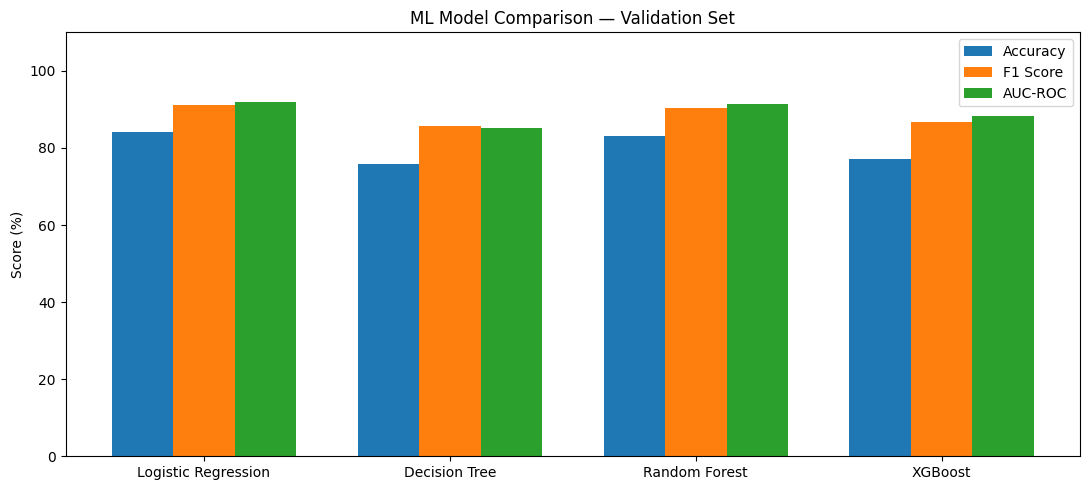

In [79]:
metrics = ['Accuracy', 'F1 Score', 'AUC-ROC']
models  = results_df['Model']
x       = np.arange(len(models))
width   = 0.25

fig, ax = plt.subplots(figsize=(11, 5))

for i, metric in enumerate(metrics):
    ax.bar(x + i*width, results_df[metric], width, label=metric)

ax.set_xticks(x + width)
ax.set_xticklabels(models, fontsize=10)
ax.set_ylabel('Score (%)')
ax.set_title('ML Model Comparison — Validation Set')
ax.legend()
ax.set_ylim(0, 110)
plt.tight_layout()
plt.show()

In [81]:
import joblib, os

BASE = "/Users/prashantkumar/Desktop/New_Project/Backend"

# Using 'xgb' instead of 'model'
joblib.dump(xgb,    os.path.join(BASE, "model.pkl"))   # <-- fixed
joblib.dump(scaler,  os.path.join(BASE, "scaler.pkl"))
joblib.dump(le_op,   os.path.join(BASE, "le_op.pkl"))
joblib.dump(le_user, os.path.join(BASE, "le_user.pkl"))

for f in ["model.pkl", "scaler.pkl", "le_op.pkl", "le_user.pkl"]:
    size = os.path.getsize(os.path.join(BASE, f))
    print(f"{f}: {size:,} bytes")

model.pkl: 170,093 bytes
scaler.pkl: 1,143 bytes
le_op.pkl: 646 bytes
le_user.pkl: 523 bytes
